# g0 sim sweep — per-founder h distributions vs truth

**Created 2026-05-21.** Ground-truth tests of cactus_em with filt2 baseline vs subsamp_raw cn, on g0 uniform pools sampled from the full 231 panel (no recomb).

Sims (9 total): pool size n ∈ {10, 50, 200, 231}, with compositions varying cactus/PG balance for small n.

Truth per sim: h = 1/n for sampled founders, 0 otherwise. Side label cactus/PG from `data/founder_split_cactus_pg.json`.

Methods compared:
- **filt2** (`cn_full_231_v3qc_v3_filt2`) — current production
- **subsamp_raw** (`cn_full_231_v3qc_v3_subsampMedian_refilt2`) — median-target stratum subsample of raw v3qc_v3

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')
OUT = ROOT/'scratch/g0_sweep_h_test'
SIM_BASE = ROOT/'sims/visor_freqk/g0_sweep'

with open(ROOT/'data/founder_split_cactus_pg.json') as fh:
    split = json.load(fh)
cactus_set = set(map(str, split['cactus']))

SIMS = [
    ('g0_n10_rep0_cact',  'n=10, 8C+2PG (cact-heavy)'),
    ('g0_n10_rep1_bal',   'n=10, 3C+7PG (balanced)'),
    ('g0_n10_rep2_pg',    'n=10, 1C+9PG (pg-heavy)'),
    ('g0_n50_rep0_cact',  'n=50, 40C+10PG (cact-heavy)'),
    ('g0_n50_rep1_bal',   'n=50, 17C+33PG (balanced)'),
    ('g0_n50_rep2_pg',    'n=50, 5C+45PG (pg-heavy)'),
    ('g0_n200_rep0_rand', 'n=200, random rep0'),
    ('g0_n200_rep1_rand', 'n=200, random rep1'),
    ('g0_n231_rep0_rand', 'n=231 (all founders)'),
]

data = {}
for sim_name, label in SIMS:
    truth_df = pd.read_csv(SIM_BASE/sim_name/'h_truth.tsv', sep='\t', dtype={'founder':str})
    truth = dict(zip(truth_df.founder, truth_df.h_truth))
    z_f = np.load(OUT/f'filt2_{sim_name}.h_sweep.npz', allow_pickle=True)
    z_s = np.load(OUT/f'subsamp_{sim_name}.h_sweep.npz', allow_pickle=True)
    founders = np.asarray(z_f['founders']).astype(str)
    h_truth  = np.array([truth.get(f, 0.0) for f in founders])
    h_filt2  = z_f['h_proj_per_alpha'][0]
    h_subs   = z_s['h_proj_per_alpha'][0]
    side = np.array(['cactus' if x in cactus_set else 'PG' for x in founders])
    data[sim_name] = dict(founders=founders, truth=h_truth, filt2=h_filt2,
                          subsamp=h_subs, side=side, label=label)
    print(f'  loaded {sim_name}: {len(founders)} founders, truth-nonzero={int((h_truth>0).sum())}')

/tmp/ipykernel_831155/4064345517.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


  loaded g0_n10_rep0_cact: 231 founders, truth-nonzero=10
  loaded g0_n10_rep1_bal: 231 founders, truth-nonzero=10
  loaded g0_n10_rep2_pg: 231 founders, truth-nonzero=10
  loaded g0_n50_rep0_cact: 231 founders, truth-nonzero=50
  loaded g0_n50_rep1_bal: 231 founders, truth-nonzero=50
  loaded g0_n50_rep2_pg: 231 founders, truth-nonzero=50
  loaded g0_n200_rep0_rand: 231 founders, truth-nonzero=200
  loaded g0_n200_rep1_rand: 231 founders, truth-nonzero=200
  loaded g0_n231_rep0_rand: 231 founders, truth-nonzero=231


## Per-sim h distributions, x = founder sorted by truth h ascending (visual continuity)

Truth = red dashed bar at 1/n (where the present founders sit). Founders with truth=0 cluster at left. Cactus = blue ×, PG = orange ×.

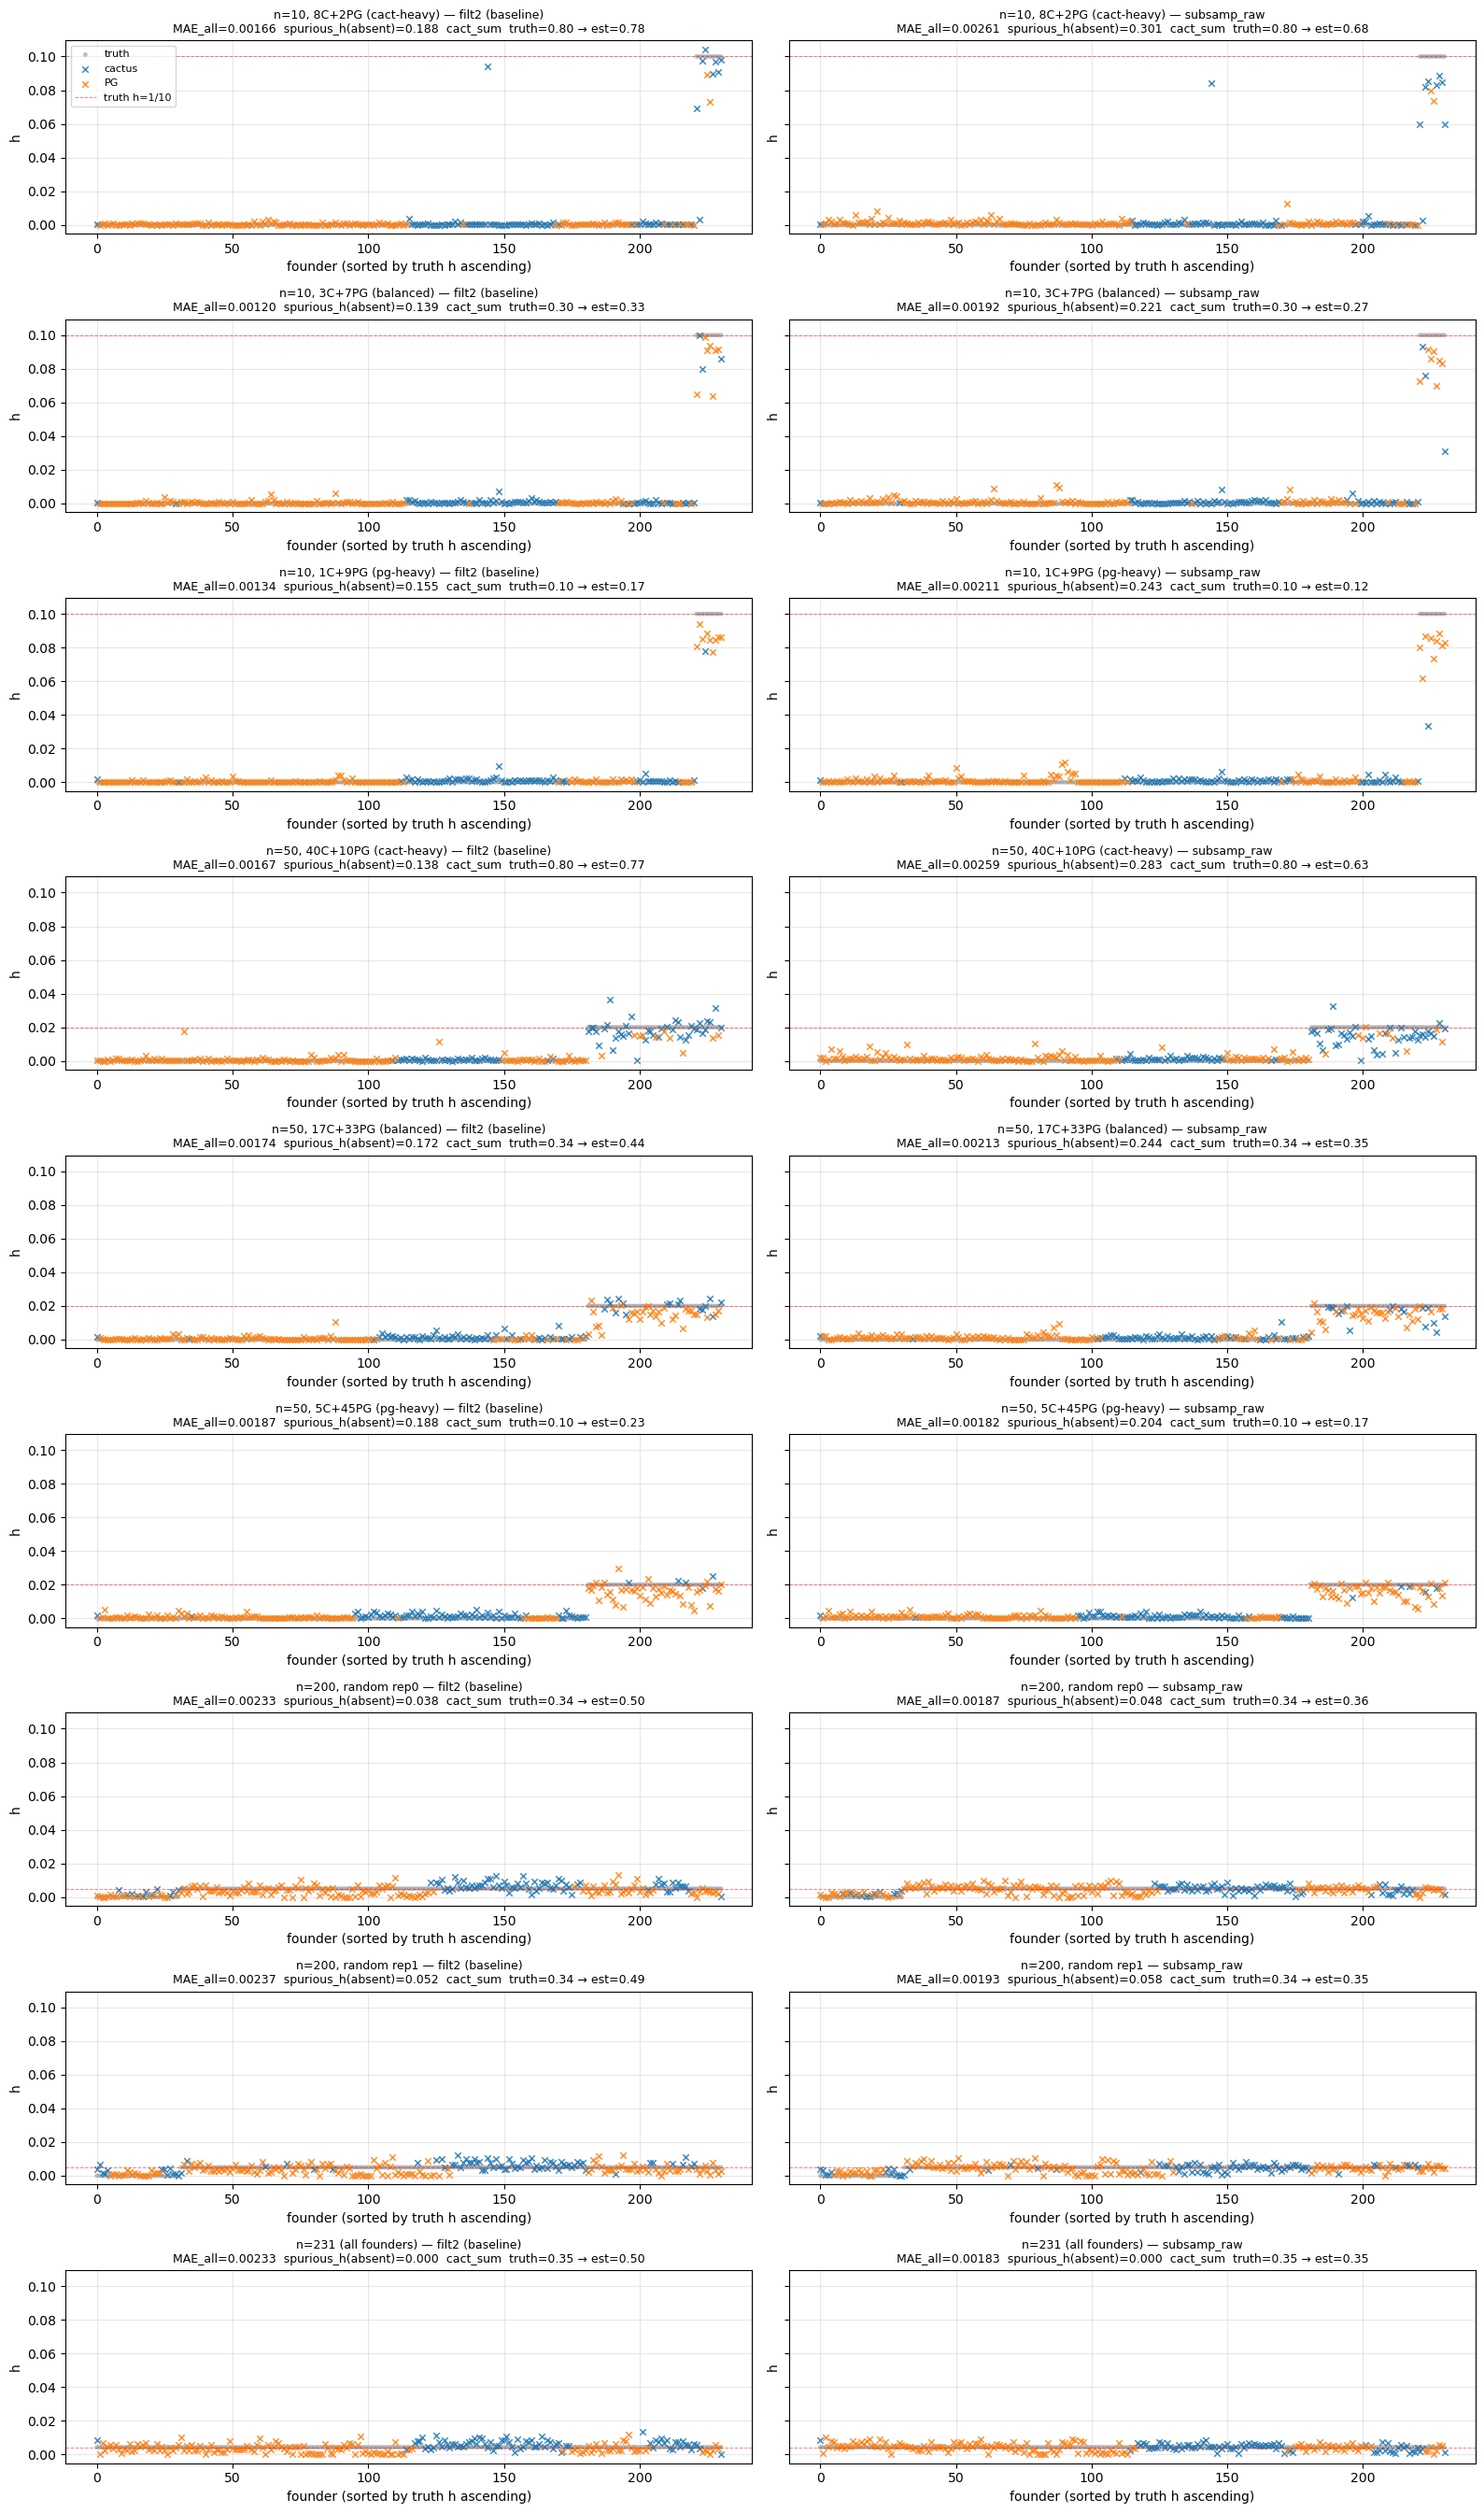

In [2]:
CACT_BLUE = '#1f77b4'
PG_ORANGE = '#ff7f0e'
GRAY = '#808080'

n_sims = len(SIMS)
fig, axes = plt.subplots(n_sims, 2, figsize=(16, 3.0*n_sims), sharex=False, sharey=True)
for row, (sim_name, label) in enumerate(SIMS):
    d = data[sim_name]
    # Order founders by truth ascending (so present founders are on the right)
    order = np.argsort(d['truth'])
    x = np.arange(len(order))
    truth_sorted = d['truth'][order]
    side_sorted  = d['side'][order]
    is_c = side_sorted == 'cactus'
    is_p = side_sorted == 'PG'
    truth_h = float(truth_sorted.max())
    n_in_pool = int((truth_sorted > 0).sum())
    for col, (method, h_method, method_label) in enumerate([
        ('filt2',   d['filt2'],   'filt2 (baseline)'),
        ('subsamp', d['subsamp'], 'subsamp_raw'),
    ]):
        ax = axes[row, col]
        h_sorted = h_method[order]
        # truth as gray dots (1/n at present positions, 0 elsewhere)
        ax.scatter(x, truth_sorted, c=GRAY, marker='o', s=12, alpha=0.5,
                   edgecolor='none', label='truth' if row==0 and col==0 else None)
        # method points by side
        ax.scatter(x[is_c], h_sorted[is_c], c=CACT_BLUE, marker='x', s=22, lw=1.1, alpha=0.85,
                   label='cactus' if row==0 and col==0 else None)
        ax.scatter(x[is_p], h_sorted[is_p], c=PG_ORANGE, marker='x', s=22, lw=1.1, alpha=0.85,
                   label='PG' if row==0 and col==0 else None)
        # truth reference line
        ax.axhline(truth_h, color='red', ls='--', lw=0.7, alpha=0.5,
                   label=f'truth h=1/{n_in_pool}' if row==0 and col==0 else None)
        # metrics
        mae_all = float(np.mean(np.abs(h_method - d['truth'])))
        mae_pres = float(np.mean(np.abs(h_method[d['truth']>0] - d['truth'][d['truth']>0]))) if (d['truth']>0).any() else float('nan')
        spur     = float(h_method[d['truth']==0].sum())
        est_C = float(h_method[d['side']=='cactus'].sum())
        truth_C= float(d['truth'][d['side']=='cactus'].sum())
        ax.set_title(f'{label} — {method_label}\nMAE_all={mae_all:.5f}  spurious_h(absent)={spur:.3f}  '
                     f'cact_sum  truth={truth_C:.2f} → est={est_C:.2f}', fontsize=9)
        ax.set_xlabel('founder (sorted by truth h ascending)')
        ax.set_ylabel('h')
        ax.grid(alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('plots/G0_SWEEP_per_sim_panels.png', dpi=130, bbox_inches='tight')
plt.show()

## Scatter: estimated h vs truth h, per sim (y=x is perfect)

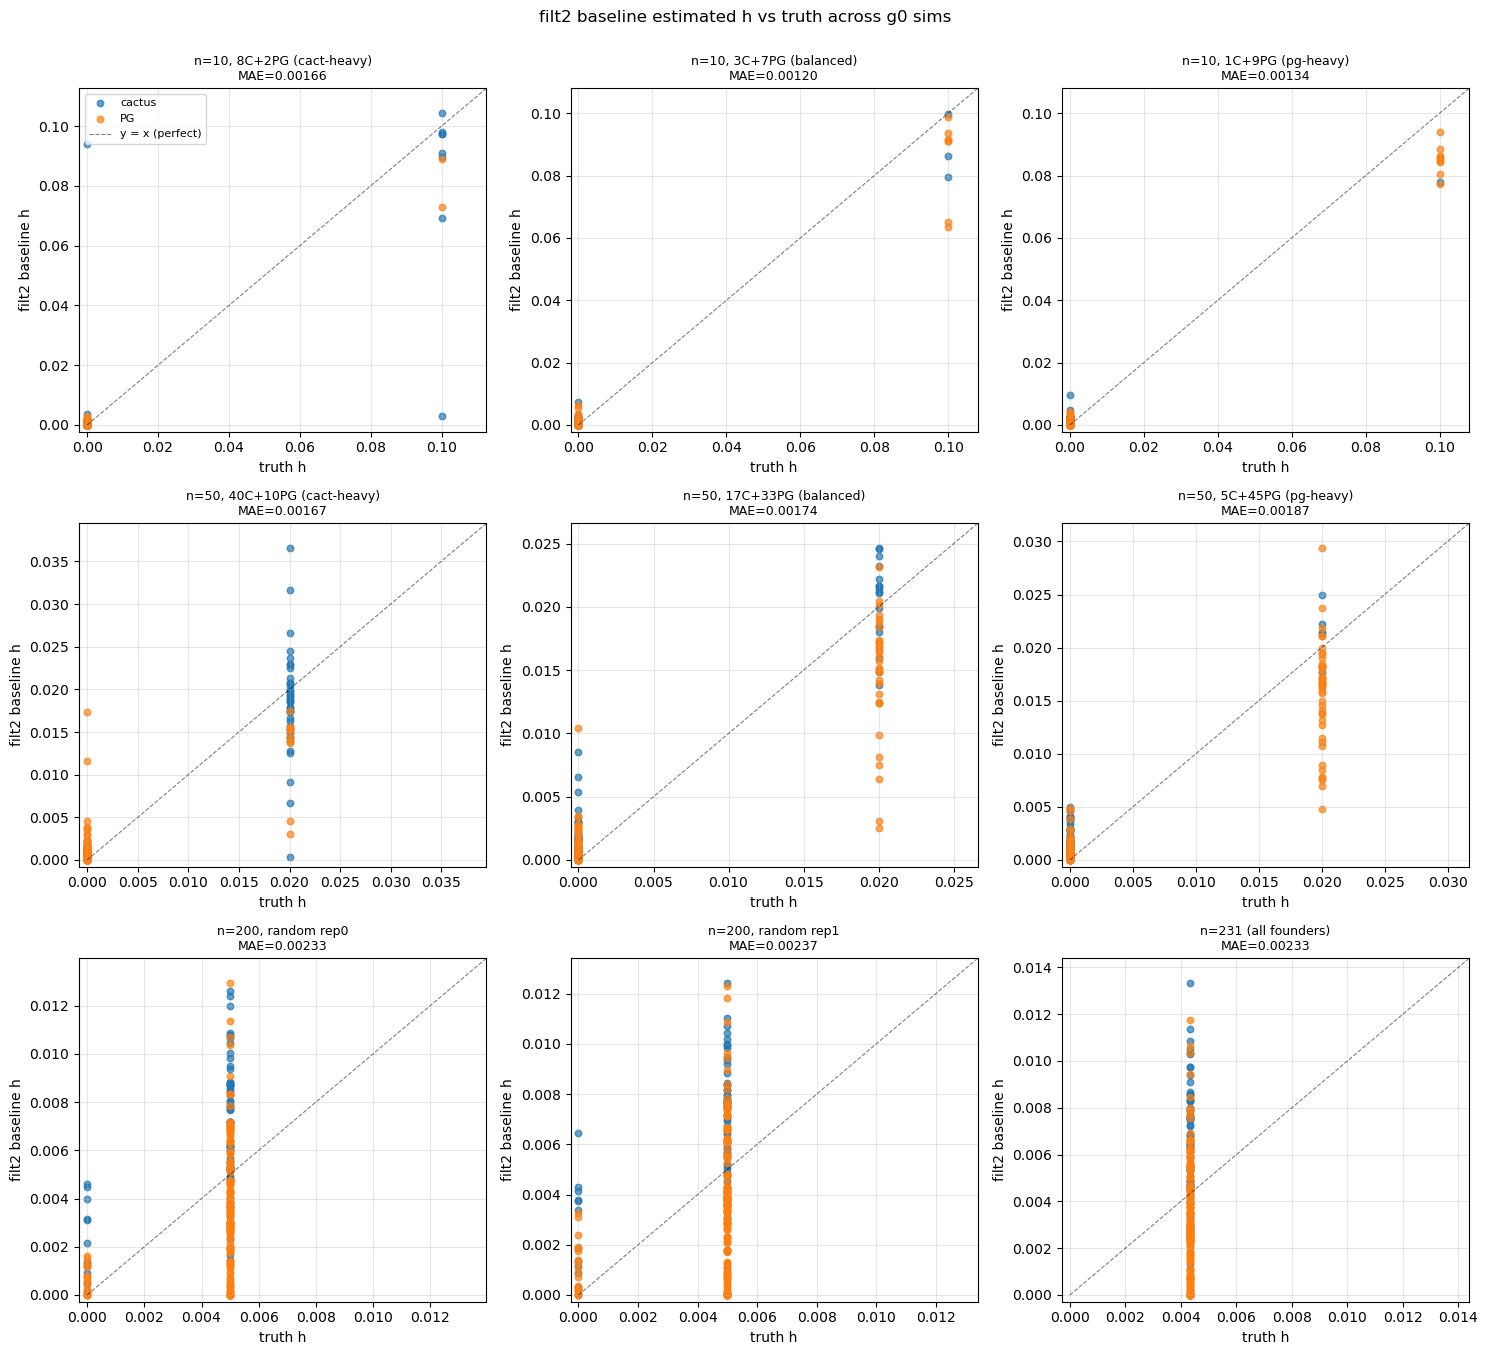

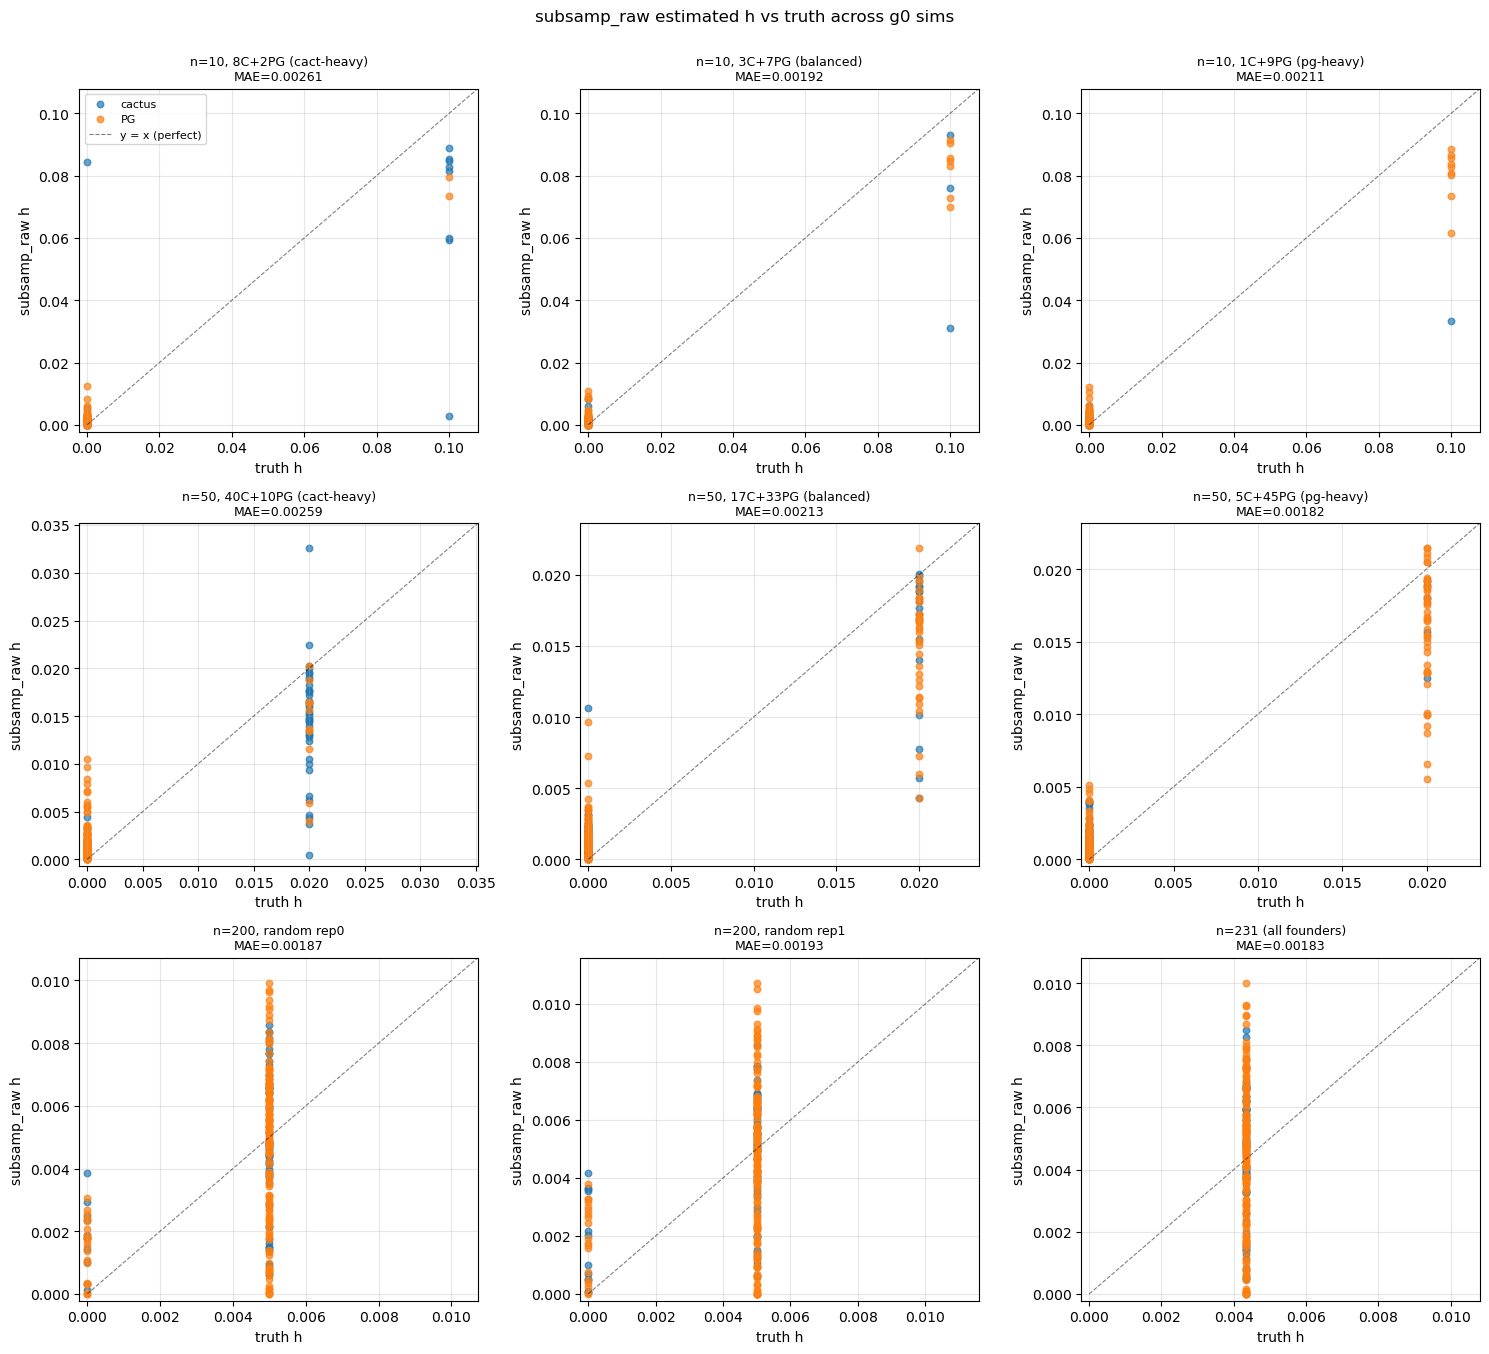

In [3]:
ncols = 3
nrows = (n_sims + ncols - 1) // ncols
for method, hkey, mlabel, savetag in [('filt2', 'filt2', 'filt2 baseline', 'filt2'),
                                       ('subsamp', 'subsamp', 'subsamp_raw', 'subsamp')]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), sharex=False, sharey=False)
    axes = np.atleast_2d(axes).flatten()
    for i, (sim_name, label) in enumerate(SIMS):
        d = data[sim_name]
        ax = axes[i]
        is_c = d['side']=='cactus'; is_p = d['side']=='PG'
        ax.scatter(d['truth'][is_c], d[hkey][is_c], c=CACT_BLUE, alpha=0.7, s=22, label='cactus')
        ax.scatter(d['truth'][is_p], d[hkey][is_p], c=PG_ORANGE, alpha=0.7, s=22, label='PG')
        lim = max(d['truth'].max(), d[hkey].max())*1.08
        ax.plot([0, lim],[0, lim], 'k--', lw=0.8, alpha=0.5, label='y = x (perfect)')
        ax.set_xlim(-lim*0.02, lim); ax.set_ylim(-lim*0.02, lim)
        mae = float(np.mean(np.abs(d[hkey] - d['truth'])))
        ax.set_title(f'{label}\nMAE={mae:.5f}', fontsize=9)
        ax.set_xlabel('truth h'); ax.set_ylabel(f'{mlabel} h')
        ax.grid(alpha=0.3)
        if i==0: ax.legend(fontsize=8)
    for j in range(i+1, len(axes)): axes[j].axis('off')
    fig.suptitle(f'{mlabel} estimated h vs truth across g0 sims', fontsize=12, y=1.0)
    plt.tight_layout()
    plt.savefig(f'plots/G0_SWEEP_scatter_{savetag}_vs_truth.png', dpi=130, bbox_inches='tight')
    plt.show()

## Side-balance summary: estimated cactus sum vs truth cactus sum

Line across sims. Both filt2 and subsamp shown.

              sim                       label   n  n_cactus  n_pg  truth_C  truth_P  filt2_C  filt2_P  subsamp_C  subsamp_P  filt2_MAE  subsamp_MAE  filt2_spur  subsamp_spur  filt2_9992  subsamp_9992  truth_9992
 g0_n10_rep0_cact   n=10, 8C+2PG (cact-heavy)  10         8     2  0.80000 0.200000 0.776126 0.223874   0.677530   0.322470   0.001665     0.002608    0.188009      0.301223    0.000090      0.000120    0.000000
  g0_n10_rep1_bal     n=10, 3C+7PG (balanced)  10         3     7  0.30000 0.700000 0.333154 0.666846   0.271251   0.728749   0.001201     0.001916    0.138685      0.221321    0.000211      0.000069    0.000000
   g0_n10_rep2_pg     n=10, 1C+9PG (pg-heavy)  10         1     9  0.10000 0.900000 0.168870 0.831130   0.124198   0.875802   0.001341     0.002105    0.154877      0.243131    0.000244      0.000414    0.000000
 g0_n50_rep0_cact n=50, 40C+10PG (cact-heavy)  50        40    10  0.80000 0.200000 0.765028 0.234972   0.632231   0.367769   0.001668     0.002588    0

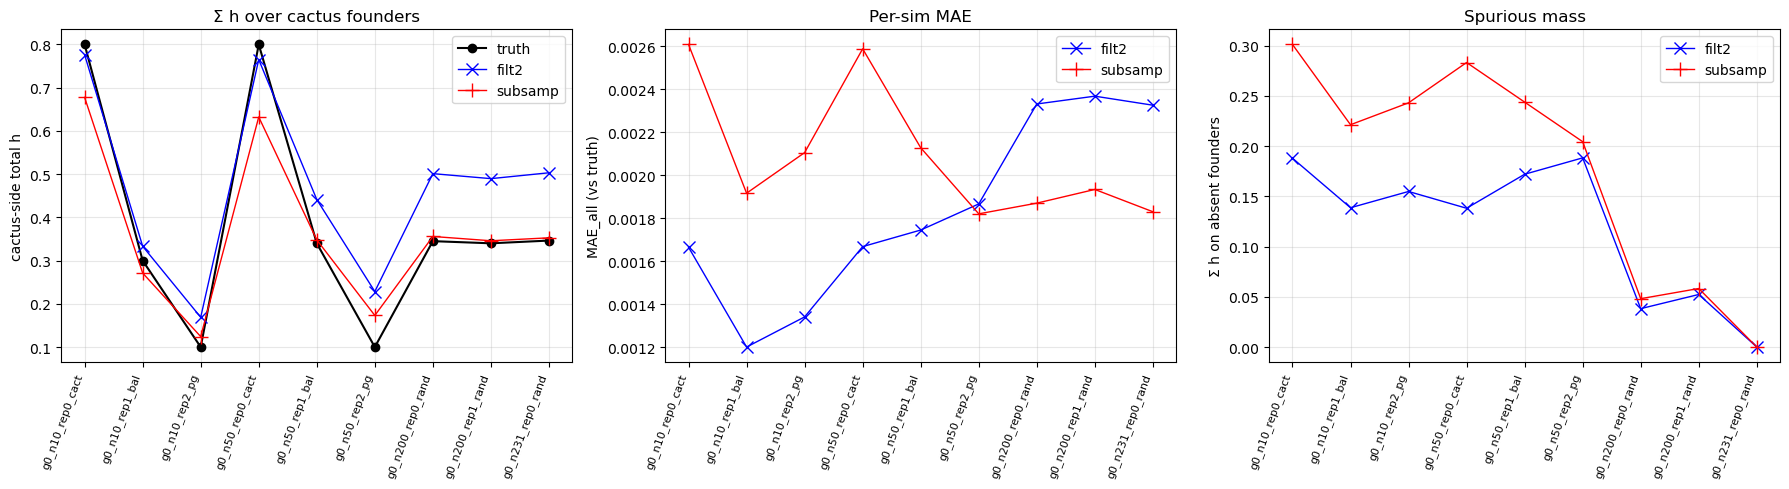

In [4]:
rows = []
for sim_name, label in SIMS:
    d = data[sim_name]
    n_in = int((d['truth']>0).sum())
    n_c_in = int(((d['truth']>0) & (d['side']=='cactus')).sum())
    truth_C = float(d['truth'][d['side']=='cactus'].sum())
    truth_P = float(d['truth'][d['side']=='PG'].sum())
    rows.append({'sim': sim_name, 'label': label,
                 'n': n_in, 'n_cactus': n_c_in, 'n_pg': n_in - n_c_in,
                 'truth_C': truth_C, 'truth_P': truth_P,
                 'filt2_C':   float(d['filt2'][d['side']=='cactus'].sum()),
                 'filt2_P':   float(d['filt2'][d['side']=='PG'].sum()),
                 'subsamp_C': float(d['subsamp'][d['side']=='cactus'].sum()),
                 'subsamp_P': float(d['subsamp'][d['side']=='PG'].sum()),
                 'filt2_MAE':   float(np.mean(np.abs(d['filt2'] - d['truth']))),
                 'subsamp_MAE': float(np.mean(np.abs(d['subsamp'] - d['truth']))),
                 'filt2_spur':   float(d['filt2'][d['truth']==0].sum()),
                 'subsamp_spur': float(d['subsamp'][d['truth']==0].sum()),
                 'filt2_9992':   float(d['filt2'][d['founders']=='9992'][0]),
                 'subsamp_9992': float(d['subsamp'][d['founders']=='9992'][0]),
                 'truth_9992':   float(d['truth'][d['founders']=='9992'][0]),
                })
S = pd.DataFrame(rows)
print(S.to_string(index=False))
S.to_csv(ROOT/'scratch/g0_sweep_summary.tsv', sep='\t', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_pos = np.arange(len(S))
# (1) cactus sum: truth vs filt2 vs subsamp
ax = axes[0]
ax.plot(x_pos, S['truth_C'], 'k-o', label='truth', lw=1.5)
ax.plot(x_pos, S['filt2_C'], 'b-x', label='filt2', lw=1, ms=8)
ax.plot(x_pos, S['subsamp_C'], 'r-+', label='subsamp', lw=1, ms=10)
ax.set_xticks(x_pos); ax.set_xticklabels(S['sim'], rotation=70, ha='right', fontsize=8)
ax.set_ylabel('cactus-side total h'); ax.set_title('Σ h over cactus founders'); ax.grid(alpha=0.3); ax.legend()
# (2) MAE
ax = axes[1]
ax.plot(x_pos, S['filt2_MAE'], 'b-x', label='filt2', lw=1, ms=8)
ax.plot(x_pos, S['subsamp_MAE'], 'r-+', label='subsamp', lw=1, ms=10)
ax.set_xticks(x_pos); ax.set_xticklabels(S['sim'], rotation=70, ha='right', fontsize=8)
ax.set_ylabel('MAE_all (vs truth)'); ax.set_title('Per-sim MAE'); ax.grid(alpha=0.3); ax.legend()
# (3) spurious mass on absent founders
ax = axes[2]
ax.plot(x_pos, S['filt2_spur'], 'b-x', label='filt2', lw=1, ms=8)
ax.plot(x_pos, S['subsamp_spur'], 'r-+', label='subsamp', lw=1, ms=10)
ax.set_xticks(x_pos); ax.set_xticklabels(S['sim'], rotation=70, ha='right', fontsize=8)
ax.set_ylabel('Σ h on absent founders'); ax.set_title('Spurious mass'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('plots/G0_SWEEP_aggregate_metrics.png', dpi=130, bbox_inches='tight')
plt.show()

## Dog-4 (founder 9992) across all sims

Is Dog-4's SEEDMIX over-credit reproduced anywhere with known truth? No — see numbers.

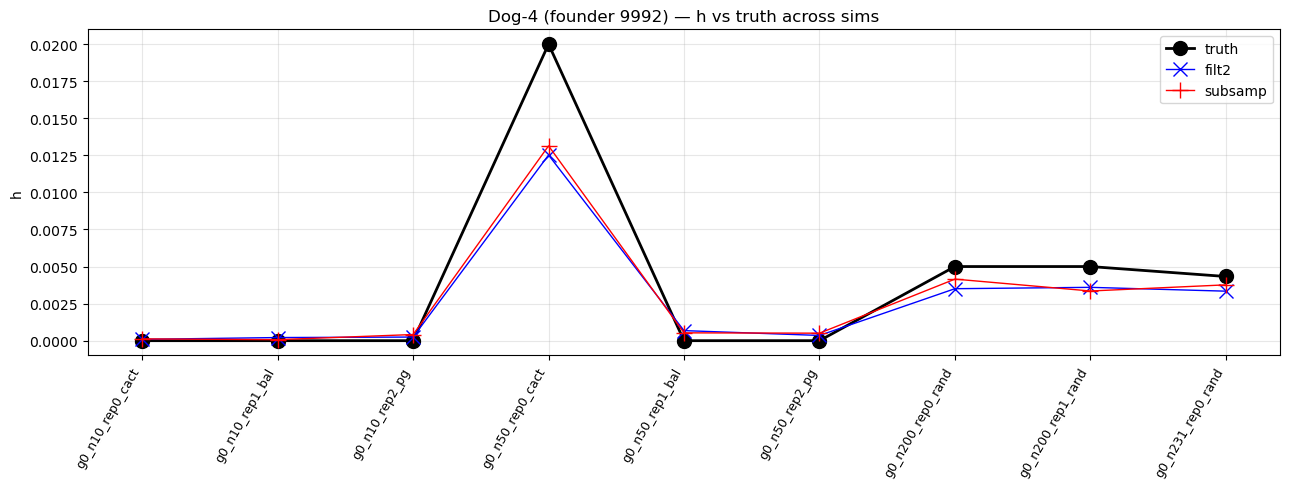


--- Dog-4 raw numbers ---
              sim  truth_9992  filt2_9992  subsamp_9992
 g0_n10_rep0_cact    0.000000    0.000090      0.000120
  g0_n10_rep1_bal    0.000000    0.000211      0.000069
   g0_n10_rep2_pg    0.000000    0.000244      0.000414
 g0_n50_rep0_cact    0.020000    0.012521      0.013139
  g0_n50_rep1_bal    0.000000    0.000678      0.000528
   g0_n50_rep2_pg    0.000000    0.000353      0.000505
g0_n200_rep0_rand    0.005000    0.003506      0.004153
g0_n200_rep1_rand    0.005000    0.003598      0.003351
g0_n231_rep0_rand    0.004329    0.003339      0.003766


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
x_pos = np.arange(len(S))
ax.plot(x_pos, S['truth_9992'], 'k-o', label='truth', lw=2, ms=10)
ax.plot(x_pos, S['filt2_9992'], 'b-x', label='filt2', lw=1, ms=10)
ax.plot(x_pos, S['subsamp_9992'], 'r-+', label='subsamp', lw=1, ms=12)
ax.set_xticks(x_pos); ax.set_xticklabels(S['sim'], rotation=60, ha='right', fontsize=9)
ax.set_ylabel('h')
ax.set_title('Dog-4 (founder 9992) — h vs truth across sims')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/G0_SWEEP_dog4_9992.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n--- Dog-4 raw numbers ---')
print(S[['sim','truth_9992','filt2_9992','subsamp_9992']].to_string(index=False))